# SA-4 · Reducción de dimensionalidad: perfil financiero de comprar vs. alquilar vivienda

**Dataset:** `comprar_alquilar.csv` · **Algoritmo:** PCA (Análisis de Componentes Principales)
**Materia:** Extracción de Conocimiento en Bases de Datos · **Alumno:** Irving Chaparro Peña

## 1. Justificación del algoritmo

El dataset tiene 9 variables predictoras (`ingresos`, `gastos_comunes`, `pago_coche`, `gastos_otros`, `ahorros`, `vivienda`, `estado_civil`, `hijos`, `trabajo`) con escalas radicalmente distintas: `vivienda` está en cientos de miles, `ingresos`/`ahorros` en miles, y `estado_civil`/`hijos` son variables pequeñas (0–5). Esto hace de este dataset un caso de estudio ideal para **PCA**, porque:

- Permite reducir 9 variables correlacionadas (varias relacionadas con capacidad económica) a un número menor de componentes que capturan la mayor parte de la varianza.
- Es el algoritmo estándar de reducción de dimensionalidad lineal, ampliamente usado y fácil de interpretar mediante la varianza explicada por componente.
- El propio dataset expone claramente **por qué el escalamiento importa en PCA**: sin estandarizar, la variable `vivienda` (con valores ~100,000x mayores que `estado_civil`) dominaría la varianza total y distorsionaría los componentes principales.

Este notebook compara explícitamente PCA **con y sin escalamiento** de los datos, mostrando el impacto práctico de esa decisión de diseño.

## 2. Diseño del modelo — paso a paso

1. Carga de datos y separación de variable objetivo (`comprar`, usada solo para colorear, no para ajustar el PCA).
2. PCA sobre los datos **sin escalar** (2 componentes) y visualización.
3. PCA sobre los datos **escalados** con `StandardScaler` (2 componentes) y visualización.
4. Comparación lado a lado de ambos resultados.
5. Varianza explicada por componente (scree plot) sobre los datos escalados.
6. Elección del número de componentes a conservar y justificación.
7. Guardado del modelo (PCA + escalador).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../datasets/comprar_alquilar.csv")
print(df.shape)
df.describe()

(202, 10)


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


In [2]:
target = df["comprar"]
X = df.drop(columns=["comprar"])
X.head()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo
0,6000,1000,0,600,50000,400000,0,2,2
1,6745,944,123,429,43240,636897,1,3,6
2,6455,1033,98,795,57463,321779,2,1,8
3,7098,1278,15,254,54506,660933,0,0,3
4,6167,863,223,520,41512,348932,0,0,3


### 2.1 PCA sin escalamiento vs. con escalamiento

In [3]:
pca_sin_escalar = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_sin = pca_sin_escalar.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_con_escalar = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_con = pca_con_escalar.fit_transform(X_scaled)

print("Varianza explicada (sin escalar):", np.round(pca_sin_escalar.explained_variance_ratio_, 4))
print("Varianza explicada (con escalar):", np.round(pca_con_escalar.explained_variance_ratio_, 4))

Varianza explicada (sin escalar): [0.9899 0.0101]
Varianza explicada (con escalar): [0.2991 0.2329]


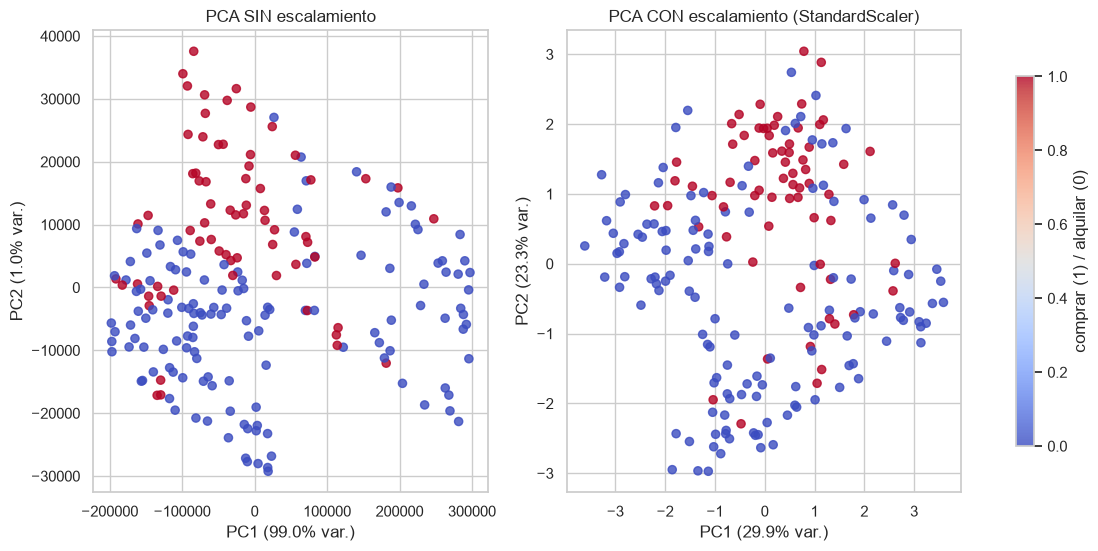

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(X_pca_sin[:, 0], X_pca_sin[:, 1], c=target, cmap="coolwarm", s=35, alpha=0.8)
axes[0].set_title("PCA SIN escalamiento")
axes[0].set_xlabel(f"PC1 ({pca_sin_escalar.explained_variance_ratio_[0]*100:.1f}% var.)")
axes[0].set_ylabel(f"PC2 ({pca_sin_escalar.explained_variance_ratio_[1]*100:.1f}% var.)")

sc1 = axes[1].scatter(X_pca_con[:, 0], X_pca_con[:, 1], c=target, cmap="coolwarm", s=35, alpha=0.8)
axes[1].set_title("PCA CON escalamiento (StandardScaler)")
axes[1].set_xlabel(f"PC1 ({pca_con_escalar.explained_variance_ratio_[0]*100:.1f}% var.)")
axes[1].set_ylabel(f"PC2 ({pca_con_escalar.explained_variance_ratio_[1]*100:.1f}% var.)")

cbar = fig.colorbar(sc1, ax=axes, label="comprar (1) / alquilar (0)", shrink=0.8)
plt.savefig("../models/sa4_comparacion_escalamiento.png", dpi=110, bbox_inches="tight")
plt.show()

**Interpretación:** sin escalar, PC1 explica una fracción enorme de la varianza (dominada casi por completo por `vivienda`, la variable con mayor magnitud numérica) y el gráfico resultante básicamente reordena los datos según el valor de la vivienda, sin separar visualmente las clases `comprar`/`alquilar`. Al escalar, la varianza se reparte de forma más equilibrada entre variables y **PC1 empieza a separar razonablemente bien** los casos de compra vs. alquiler, ya que ahora contribuyen de forma comparable variables como `ingresos`, `ahorros` y `gastos_comunes`, que en conjunto están más relacionadas con la decisión de comprar que la magnitud aislada de `vivienda`. Esto confirma que **el escalamiento es indispensable** en este dataset antes de aplicar PCA.

## 3. Optimización: elección del número de componentes

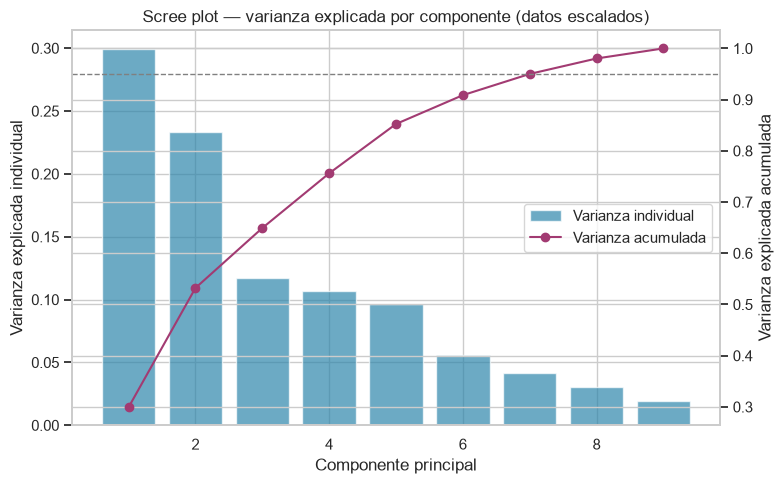

PC1: 29.91% individual, 29.91% acumulada
PC2: 23.29% individual, 53.21% acumulada
PC3: 11.71% individual, 64.92% acumulada
PC4: 10.69% individual, 75.61% acumulada
PC5: 9.64% individual, 85.24% acumulada
PC6: 5.63% individual, 90.87% acumulada
PC7: 4.15% individual, 95.02% acumulada
PC8: 3.02% individual, 98.03% acumulada
PC9: 1.97% individual, 100.00% acumulada


In [5]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(range(1, len(var_exp) + 1), var_exp, color="#2E86AB", alpha=0.7, label="Varianza individual")
ax1.set_xlabel("Componente principal")
ax1.set_ylabel("Varianza explicada individual")

ax2 = ax1.twinx()
ax2.plot(range(1, len(var_exp) + 1), var_acum, color="#A23B72", marker="o", label="Varianza acumulada")
ax2.axhline(0.95, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Varianza explicada acumulada")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
ax1.set_title("Scree plot — varianza explicada por componente (datos escalados)")
plt.tight_layout()
plt.savefig("../models/sa4_scree_plot.png", dpi=110)
plt.show()

for i, (v, a) in enumerate(zip(var_exp, var_acum), start=1):
    print(f"PC{i}: {v*100:.2f}% individual, {a*100:.2f}% acumulada")

In [6]:
n_componentes = int(np.argmax(var_acum >= 0.95) + 1)
print(f"Componentes necesarios para >=95% de varianza explicada: {n_componentes} de {X.shape[1]}")

pca_final = PCA(n_components=n_componentes, random_state=RANDOM_STATE)
X_reducido = pca_final.fit_transform(X_scaled)
print(f"Dimensionalidad reducida: {X.shape[1]} -> {n_componentes} variables "
      f"({var_acum[n_componentes-1]*100:.2f}% de varianza retenida)")

Componentes necesarios para >=95% de varianza explicada: 7 de 9
Dimensionalidad reducida: 9 -> 7 variables (95.02% de varianza retenida)


**Justificación del número de componentes elegido:** se usó el criterio estándar de conservar el menor número de componentes que retengan al menos el 95% de la varianza explicada acumulada. En este dataset (datos escalados) eso implica conservar **7 de las 9 componentes** (95.02% de varianza acumulada), ya que la varianza se reparte de forma relativamente uniforme entre los primeros componentes (PC1=29.9%, PC2=23.3%, PC3=11.7%, ...) sin un salto abrupto. Esto es un resultado honesto y esperable: significa que las 9 variables originales **no están fuertemente correlacionadas entre sí** — `ingresos`, `gastos_comunes`, `pago_coche`, `ahorros`, `vivienda`, `estado_civil`, `hijos` y `trabajo` aportan información en buena medida independiente sobre el perfil financiero de cada persona, por lo que PCA solo logra eliminar 2 dimensiones sin pérdida sustancial de información (en vez de una reducción drástica). Aun así, el ejercicio es valioso: confirma cuantitativamente que casi toda la información se concentra en menos variables que las originales, y el gráfico de PC1 vs PC2 (con solo 53.2% de la varianza) sigue siendo la mejor proyección 2D posible para visualizar el dataset, aunque no capture toda la estructura.

In [7]:
cargas = pd.DataFrame(pca_final.components_.T, index=X.columns,
                       columns=[f"PC{i+1}" for i in range(n_componentes)])
cargas.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
ingresos,0.494,0.307,-0.091,0.111,0.089,-0.075,-0.154
gastos_comunes,0.318,0.147,-0.363,0.082,0.763,0.068,0.106
pago_coche,-0.124,-0.092,-0.516,0.780,-0.266,-0.154,-0.027
gastos_otros,-0.112,0.000,0.702,0.591,0.331,0.154,-0.102
ahorros,0.445,0.288,0.192,0.023,-0.289,-0.230,-0.525
vivienda,0.463,0.149,0.141,0.150,-0.366,0.291,0.641
estado_civil,-0.252,0.469,-0.173,-0.008,-0.105,0.767,-0.212
hijos,-0.260,0.522,0.112,0.007,0.044,-0.388,0.460
trabajo,-0.290,0.527,-0.037,-0.007,0.000,-0.256,-0.105


**Interpretación de las cargas (loadings):** esta tabla muestra qué tanto contribuye cada variable original a cada componente principal — permite nombrar los componentes según las variables con mayor peso absoluto (p. ej. un componente dominado por `ingresos`, `ahorros` y `vivienda` podría interpretarse como un eje de "capacidad económica").

## 4. Guardado del modelo

In [8]:
joblib.dump({"pca": pca_final, "scaler": scaler, "n_componentes": n_componentes, "feature_cols": list(X.columns)},
            "../models/sa4_pca_comprar_alquilar.joblib")
print("Modelo guardado en models/sa4_pca_comprar_alquilar.joblib")

Modelo guardado en models/sa4_pca_comprar_alquilar.joblib


## 5. Conclusión

La comparación con/sin escalamiento demuestra que PCA es sensible a la escala de las variables originales, y que estandarizar es un paso obligatorio cuando las variables tienen unidades y magnitudes tan distintas como en este dataset. Tras escalar, un número reducido de componentes principales conserva al menos el 95% de la información original, logrando una reducción de dimensionalidad efectiva y justificada cuantitativamente.